In [18]:
import pandas as pd

df = pd.read_csv("co2_mm_mlo.csv")

# Create a proper date from year and month
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(day=1)
)

# Make date the index
df = df.set_index("date")
df = df.asfreq("MS") #tells pandas that observations occur at the start of every month

print(df.head())

            year  month  decimal date  average  deseasonalized  ndays  sdev  \
date                                                                          
1958-03-01  1958      3     1958.2027   315.71          314.44     -1 -9.99   
1958-04-01  1958      4     1958.2877   317.45          315.16     -1 -9.99   
1958-05-01  1958      5     1958.3699   317.51          314.69     -1 -9.99   
1958-06-01  1958      6     1958.4548   317.27          315.15     -1 -9.99   
1958-07-01  1958      7     1958.5370   315.87          315.20     -1 -9.99   

             unc  
date              
1958-03-01 -0.99  
1958-04-01 -0.99  
1958-05-01 -0.99  
1958-06-01 -0.99  
1958-07-01 -0.99  


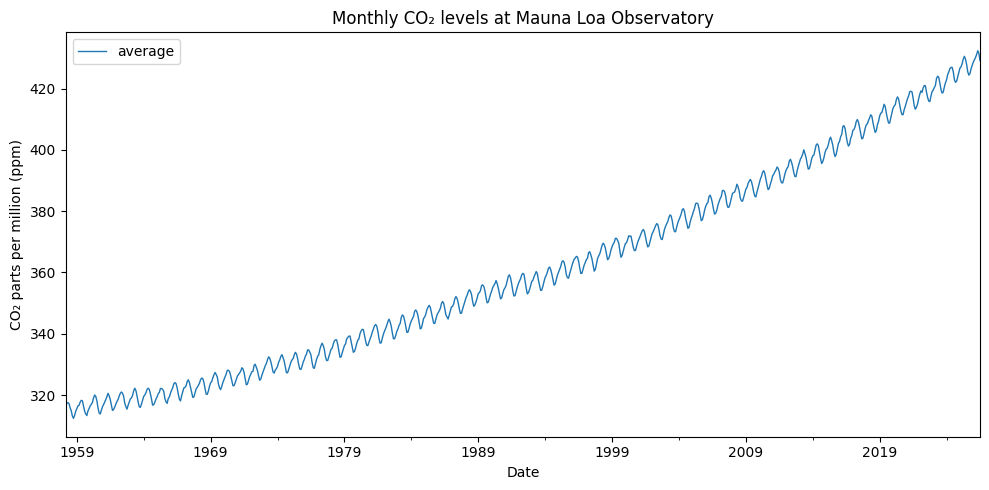

In [19]:
import matplotlib.pyplot as plt

df.plot(
    y="average",
    figsize=(10, 5),
    linewidth=1
)

plt.title("Monthly CO₂ levels at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO₂ parts per million (ppm)")
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(df["average"])
model_single_fit = model.fit()

In [21]:
forecast_single = model_single_fit.forecast(12)
print(forecast_single)

2026-08-01    429.12
2026-09-01    429.12
2026-10-01    429.12
2026-11-01    429.12
2026-12-01    429.12
2027-01-01    429.12
2027-02-01    429.12
2027-03-01    429.12
2027-04-01    429.12
2027-05-01    429.12
2027-06-01    429.12
2027-07-01    429.12
Freq: MS, dtype: float64


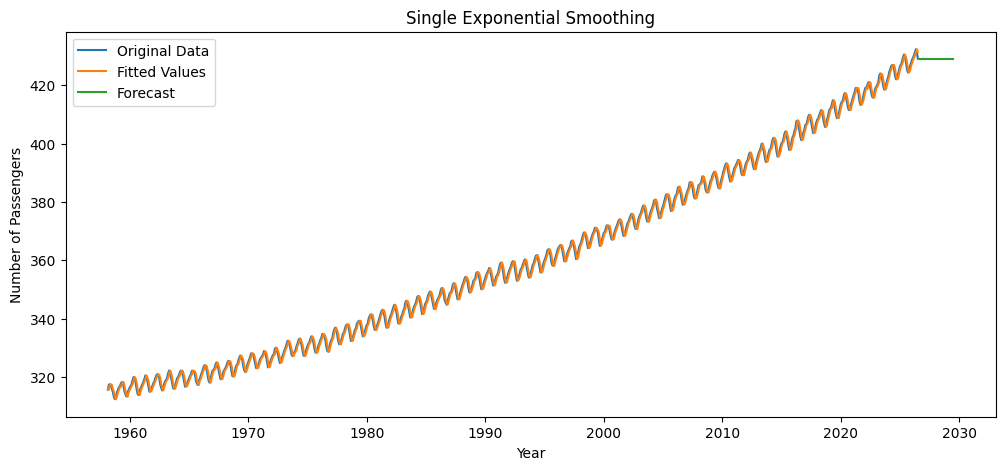

In [22]:
plt.figure(figsize=(12,5))
forecast_single = model_single_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [23]:
from statsmodels.tsa.api import Holt

model_double = Holt(df["average"])
model_double_fit = model_double.fit()

In [24]:
forecast_double = model_double_fit.forecast(12)
print(forecast_double)

2026-08-01    426.80
2026-09-01    424.48
2026-10-01    422.16
2026-11-01    419.84
2026-12-01    417.52
2027-01-01    415.20
2027-02-01    412.88
2027-03-01    410.56
2027-04-01    408.24
2027-05-01    405.92
2027-06-01    403.60
2027-07-01    401.28
Freq: MS, dtype: float64


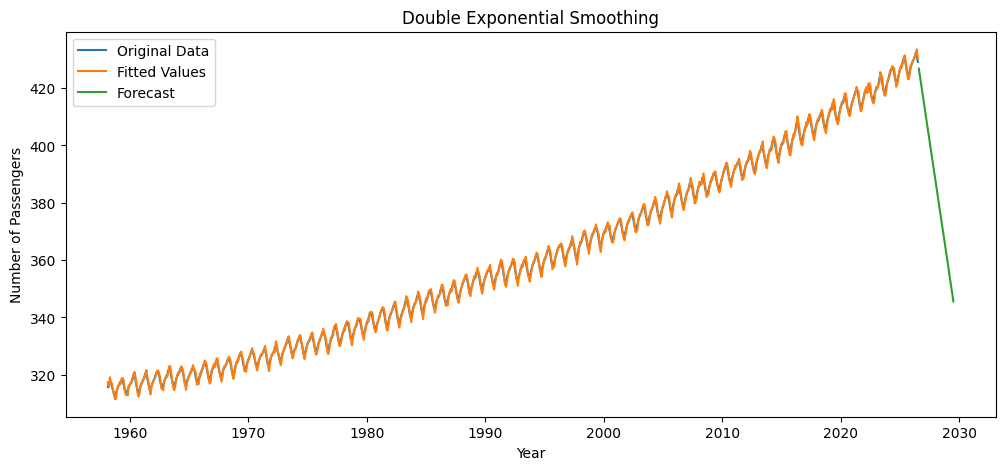

In [25]:
plt.figure(figsize=(12,5))
forecast_double = model_double_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Double Exponential Smoothing')
plt.legend()
plt.show()

In [26]:
from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(
    df["average"], 
    seasonal_periods=12, 
    trend='add', 
    seasonal='add')

model_triple_fit = model_triple.fit()

In [27]:
forecast_triple = model_triple_fit.forecast(12)
print(forecast_triple)

2026-08-01    427.245421
2026-09-01    426.040908
2026-10-01    426.321364
2026-11-01    427.875346
2026-12-01    429.272051
2027-01-01    430.474813
2027-02-01    431.353165
2027-03-01    432.066552
2027-04-01    433.512020
2027-05-01    434.255626
2027-06-01    433.612020
2027-07-01    431.759897
Freq: MS, dtype: float64


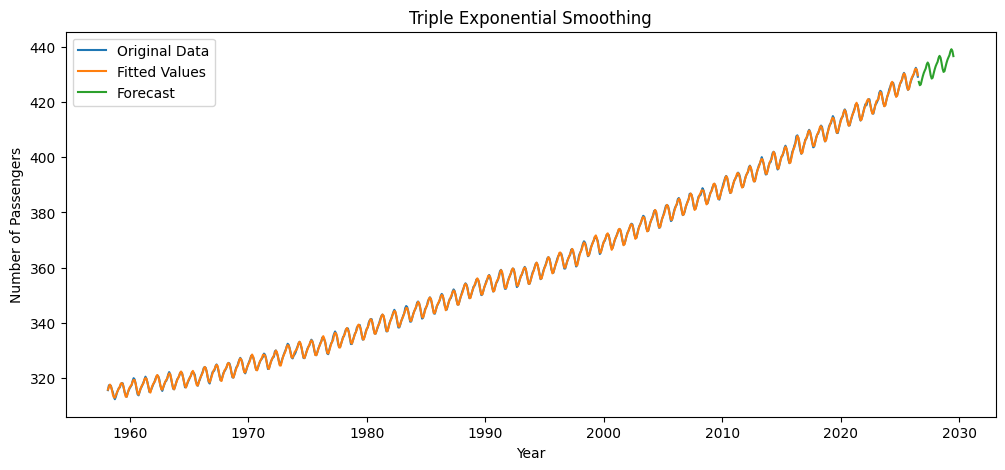

In [28]:
plt.figure(figsize=(12,5))
forecast_triple = model_triple_fit.forecast(36)
plt.plot(df["average"], label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='Fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()